# Previsão de Placares da Copa do Mundo 2026: A Otimização Completa

## 1. Aquisição e Preparação de Dados (O Setup)
Para este projeto definitivo, utilizaremos o dataset **"International football results from 1872 to 2026"** do Kaggle. 

Filtraremos os dados para manter:
1. Jogos a partir do dia **01 de Janeiro de 2022** (foco absoluto no ciclo da Copa atual).
2. **Todos os torneios** (Eliminatórias, Amistosos, Copa Ouro, Liga das Nações, etc.) para obtermos o **máximo de dados possível** até mesmo das seleções menores.
3. Como a Copa é em campo neutro, abstrairemos mandante e visitante para **Time A** e **Time B**.


In [27]:
import pandas as pd
import numpy as np
import datetime
from scipy.stats import poisson
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuração de estilo premium para os gráficos
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#1e1e1e", "figure.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

# 1. Carregando os dados
try:
    df = pd.read_csv('results.csv')
    df['date'] = pd.to_datetime(df['date'])
    
    # Filtro de datas (ciclo recente) - TODOS OS TORNEIOS MANTIDOS
    df = df[(df['date'] >= '2022-01-01')]
    
    # Tratamento de Nulos
    df = df.dropna(subset=['home_score', 'away_score'])
    df['home_score'] = df['home_score'].astype(int)
    df['away_score'] = df['away_score'].astype(int)
    
    print(f"Dataset carregado com sucesso! Total de partidas históricas (2022+): {len(df)}")
except FileNotFoundError:
    print("ERRO: O arquivo 'results.csv' não foi encontrado. Por favor, baixe do Kaggle e coloque na mesma pasta deste notebook.")


Dataset carregado com sucesso! Total de partidas históricas (2022+): 4596


## 2. Ato 1: O Estatístico Ingênuo (Modelo de Poisson Básico)

**Conceito Matemático:** Prever placares baseando-se no cruzamento de eventos independentes.
A força de ataque de uma seleção ($\lambda$) depende exclusivamente de sua própria capacidade ofensiva multiplicada pela capacidade defensiva do adversário. A equação de Poisson dita a probabilidade de $k$ gols:

$$P(k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

> **O apresentador dirá:** *"Esta é a previsão estatística pura. O problema? Ela falha duplamente: ignora que o futebol é dinâmico (subestimando empates como 0x0) e trata um jogo de 2023 com o mesmo peso de um jogo de ontem."*


Japan - Força de Ataque: 1.87, Força de Defesa: 0.53, Lambda esperado: 1.46
Tunisia - Força de Ataque: 0.96, Força de Defesa: 0.57, Lambda esperado: 0.69


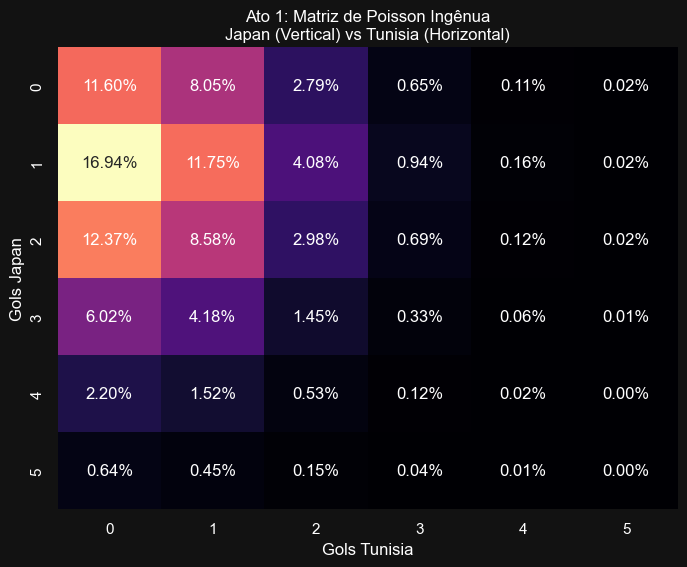

In [28]:
# Para o modelo ingênuo, calcularemos a média de gols feitos e sofridos de cada seleção.

if 'df' in locals():
    media_gols_feitos_geral = (df['home_score'].mean() + df['away_score'].mean()) / 2

    def calcular_forcas_ingenuas(time):
        jogos_casa = df[df['home_team'] == time]
        jogos_fora = df[df['away_team'] == time]
        
        gols_feitos = jogos_casa['home_score'].sum() + jogos_fora['away_score'].sum()
        gols_sofridos = jogos_casa['away_score'].sum() + jogos_fora['home_score'].sum()
        total_jogos = len(jogos_casa) + len(jogos_fora)
        
        if total_jogos == 0:
            return 1.0, 1.0 
            
        media_ataque = gols_feitos / total_jogos
        media_defesa = gols_sofridos / total_jogos
        
        ataque = media_ataque / media_gols_feitos_geral
        defesa = media_defesa / media_gols_feitos_geral
        return ataque, defesa

    # =====================================================================
    # ESCOLHA AQUI OS TIMES PARA A DEMONSTRAÇÃO
    # =====================================================================
    # Pode testar 'Brazil', 'Haiti', 'Curaçao', 'Germany', etc.
    TIME_A = 'Japan'
    TIME_B = 'Tunisia'
    # =====================================================================

    ataque_A, defesa_A = calcular_forcas_ingenuas(TIME_A)
    ataque_B, defesa_B = calcular_forcas_ingenuas(TIME_B)

    lambda_A = ataque_A * defesa_B * media_gols_feitos_geral
    lambda_B = ataque_B * defesa_A * media_gols_feitos_geral

    print(f"{TIME_A} - Força de Ataque: {ataque_A:.2f}, Força de Defesa: {defesa_A:.2f}, Lambda esperado: {lambda_A:.2f}")
    print(f"{TIME_B} - Força de Ataque: {ataque_B:.2f}, Força de Defesa: {defesa_B:.2f}, Lambda esperado: {lambda_B:.2f}")

    max_gols = 6
    prob_A = [poisson.pmf(i, lambda_A) for i in range(max_gols)]
    prob_B = [poisson.pmf(i, lambda_B) for i in range(max_gols)]

    matriz_poisson = np.outer(prob_A, prob_B)

    plt.figure(figsize=(8, 6))
    sns.heatmap(matriz_poisson, annot=True, fmt='.2%', cmap='magma', cbar=False, 
                xticklabels=range(max_gols), yticklabels=range(max_gols))
    plt.title(f"Ato 1: Matriz de Poisson Ingênua\n{TIME_A} (Vertical) vs {TIME_B} (Horizontal)", color='white')
    plt.xlabel(f"Gols {TIME_B}", color='white')
    plt.ylabel(f"Gols {TIME_A}", color='white')
    plt.show()


## 3. Ato 2: O Acadêmico Rigoroso (Dixon-Coles Vetorizado)

**Conceito Matemático:** Corrigir a interdependência dos gols e aplicar um sistema de "memória curta".

> **O apresentador dirá:** *"Ao remover o fator casa, forçar o computador a esquecer lentamente o passado e otimizar vetorialmente mais de 200 seleções simultâneas, o modelo absorve a realidade em segundos."*


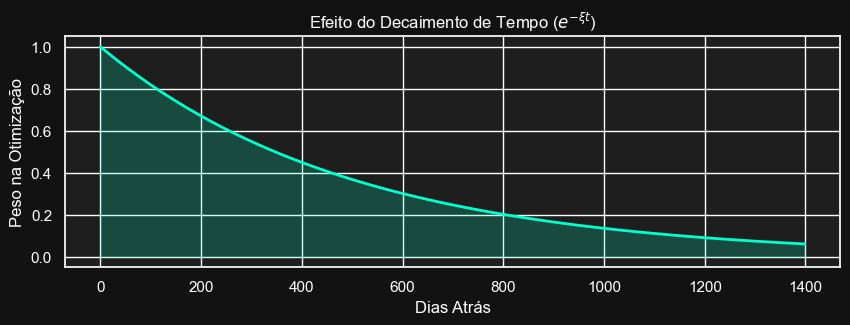

In [29]:
# Curva Exponencial de Decaimento
hoje = pd.to_datetime('today')
dias_passados = np.arange(0, 1400) 
xi = 0.002 
pesos_tempo = np.exp(-xi * dias_passados)

plt.figure(figsize=(10, 3))
plt.plot(dias_passados, pesos_tempo, color='#00ffcc', linewidth=2)
plt.title(r"Efeito do Decaimento de Tempo ($e^{-\xi t}$)", color='white')
plt.xlabel("Dias Atrás", color='white')
plt.ylabel("Peso na Otimização", color='white')
plt.fill_between(dias_passados, pesos_tempo, color='#00ffcc', alpha=0.2)
plt.show()


Otimizando globalmente 254 seleções simultaneamente...
Iniciando SLSQP Vetorizado... Deve demorar apenas entre 5 a 20 segundos!
Otimização finalizada! Fator Rho global: -0.0788


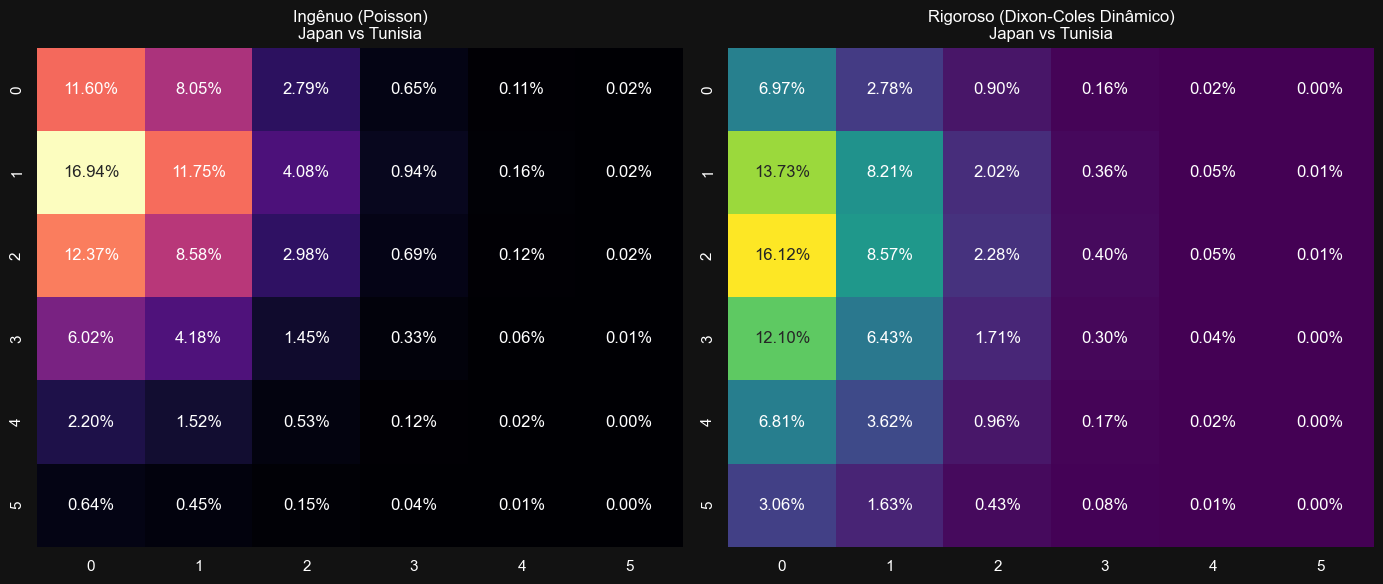

In [30]:
# Otimização do Modelo Dixon-Coles (Versão de Alta Performance)
if 'df' in locals() and not df.empty:
    # --- FILTRO LEVE (Inclui praticamente todas as seleções do mundo) ---
    times_gerais = df['home_team'].value_counts()[df['home_team'].value_counts() >= 1].index
    df_geral = df[df['home_team'].isin(times_gerais) & df['away_team'].isin(times_gerais)]
    
    selecoes = list(set(df_geral['home_team'].unique()) | set(df_geral['away_team'].unique()))
    n_selecoes = len(selecoes)
    sel_idx = {sel: i for i, sel in enumerate(selecoes)}

    def rho_correction(x, y, lambda_x, mu_y, rho):
        if x == 0 and y == 0: return 1 - (lambda_x * mu_y * rho)
        elif x == 0 and y == 1: return 1 + (lambda_x * rho)
        elif x == 1 and y == 0: return 1 + (mu_y * rho)
        elif x == 1 and y == 1: return 1 - rho
        return 1.0

    # Log-Likelihood VETORIZADA com Regularização L2 e Pesos de Torneio
    def dixon_coles_loglik_vectorized(params, df_matches, xi=0.002, lambda_reg=0.05):
        alpha = params[:n_selecoes]
        beta = params[n_selecoes:2*n_selecoes]
        rho = params[2*n_selecoes]
        
        idx_home = df_matches['home_idx'].values
        idx_away = df_matches['away_idx'].values
        x = df_matches['home_score'].values
        y = df_matches['away_score'].values
        dias = df_matches['dias_atras'].values
        peso_camp = df_matches.get('peso_camp', pd.Series(np.ones(len(x)))).values
        
        lam = np.exp(alpha[idx_home] + beta[idx_away])
        mu = np.exp(alpha[idx_away] + beta[idx_home])
        pesos = np.exp(-xi * dias) * peso_camp
        
        prob_poisson_x = poisson.pmf(x, lam)
        prob_poisson_y = poisson.pmf(y, mu)
        
        corr = np.ones_like(x, dtype=float)
        corr[(x == 0) & (y == 0)] = 1 - (lam[(x == 0) & (y == 0)] * mu[(x == 0) & (y == 0)] * rho)
        corr[(x == 0) & (y == 1)] = 1 + (lam[(x == 0) & (y == 1)] * rho)
        corr[(x == 1) & (y == 0)] = 1 + (mu[(x == 1) & (y == 0)] * rho)
        corr[(x == 1) & (y == 1)] = 1 - rho
        
        prob_final = prob_poisson_x * prob_poisson_y * corr
        log_p = np.where(prob_final <= 0, -10000, np.log(prob_final))
        
        penalty = lambda_reg * (np.sum(alpha**2) + np.sum(beta**2))
        return -np.sum(log_p * pesos) + penalty

    df_opt = df_geral.copy()
    df_opt['home_idx'] = df_opt['home_team'].map(sel_idx)
    df_opt['away_idx'] = df_opt['away_team'].map(sel_idx)
    df_opt['dias_atras'] = (hoje - df_opt['date']).dt.days

    def get_peso_campeonato(tourney):
        if 'World Cup' in tourney or 'Copa America' in tourney or 'Euro' in tourney:
            return 1.0
        elif 'Friendly' in tourney:
            return 0.5
        return 0.8
    if 'tournament' in df_opt.columns:
        df_opt['peso_camp'] = df_opt['tournament'].apply(get_peso_campeonato)
    else:
        df_opt['peso_camp'] = 1.0

    # Restrição de Ancoragem para estabilidade matemática
    def constraint_func(x):
        return sum(x[:n_selecoes])
        
    cons = [{'type': 'eq', 'fun': constraint_func}]
    
    # Smart Start: Chute inicial com médias ingênuas para acelerar convergência e fugir de mínimos locais
    media_gols_geral = (df_geral['home_score'].mean() + df_geral['away_score'].mean()) / 2
    init_alpha = np.zeros(n_selecoes)
    init_beta = np.zeros(n_selecoes)
    for sel, idx in sel_idx.items():
        jogos_casa = df_geral[df_geral['home_team'] == sel]
        jogos_fora = df_geral[df_geral['away_team'] == sel]
        total_jogos = len(jogos_casa) + len(jogos_fora)
        if total_jogos > 0:
            gf = jogos_casa['home_score'].sum() + jogos_fora['away_score'].sum()
            gs = jogos_casa['away_score'].sum() + jogos_fora['home_score'].sum()
            ataq_ing = (gf / total_jogos) / media_gols_geral
            def_ing = (gs / total_jogos) / media_gols_geral
            init_alpha[idx] = np.log(max(ataq_ing, 0.01))
            init_beta[idx] = np.log(max(def_ing, 0.01))
    
    init_alpha = init_alpha - np.mean(init_alpha) # Aplicar a constraint sum(alpha)=0 no chute inicial
    init_params = np.concatenate([init_alpha, init_beta, [0.0]])
    
    print(f"Otimizando globalmente {n_selecoes} seleções simultaneamente...")
    print("Iniciando SLSQP Vetorizado... Deve demorar apenas entre 5 a 20 segundos!")
    
    bounds = [(-4, 4)] * (2 * n_selecoes) + [(-0.5, 0.5)]
    res = minimize(dixon_coles_loglik_vectorized, init_params, args=(df_opt, xi), 
                   method='SLSQP', constraints=cons, bounds=bounds,
                   options={'maxiter': 30})
                   
    alpha_opt = res.x[:n_selecoes]
    beta_opt = res.x[n_selecoes:2*n_selecoes]
    rho_opt = res.x[2*n_selecoes]
    
    dict_ataque = {sel: alpha_opt[i] for sel, i in sel_idx.items()}
    dict_defesa = {sel: beta_opt[i] for sel, i in sel_idx.items()}
    
    print(f"Otimização finalizada! Fator Rho global: {rho_opt:.4f}")
    
    if TIME_A in dict_ataque and TIME_B in dict_ataque:
        lam_A_dc = np.exp(dict_ataque[TIME_A] + dict_defesa[TIME_B])
        lam_B_dc = np.exp(dict_ataque[TIME_B] + dict_defesa[TIME_A])
        
        matriz_dc = np.zeros((max_gols, max_gols))
        for i in range(max_gols):
            for j in range(max_gols):
                prob = poisson.pmf(i, lam_A_dc) * poisson.pmf(j, lam_B_dc)
                prob *= rho_correction(i, j, lam_A_dc, lam_B_dc, rho_opt)
                matriz_dc[i, j] = prob
                
        matriz_dc = matriz_dc / matriz_dc.sum()

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        sns.heatmap(matriz_poisson, annot=True, fmt='.2%', cmap='magma', cbar=False, 
                    ax=axes[0], xticklabels=range(max_gols), yticklabels=range(max_gols))
        axes[0].set_title(f"Ingênuo (Poisson)\n{TIME_A} vs {TIME_B}")
        
        sns.heatmap(matriz_dc, annot=True, fmt='.2%', cmap='viridis', cbar=False, 
                    ax=axes[1], xticklabels=range(max_gols), yticklabels=range(max_gols))
        axes[1].set_title(f"Rigoroso (Dixon-Coles Dinâmico)\n{TIME_A} vs {TIME_B}")
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"ERRO: As seleções '{TIME_A}' ou '{TIME_B}' não foram encontradas.")



## 4. O Veredito: Extraindo Valor (Apostas e Simulação)


In [31]:
if 'matriz_dc' in locals():
    indice_max = np.unravel_index(np.argmax(matriz_dc), matriz_dc.shape)
    gols_A_max, gols_B_max = indice_max
    prob_maxima = matriz_dc[indice_max]
    
    print(f"--- PREVISÃO FINAL: {TIME_A} x {TIME_B} ---")
    print(f"Placar Exato Mais Provável: {TIME_A} {gols_A_max} x {gols_B_max} {TIME_B} ({prob_maxima*100:.2f}%)")
    print("-" * 40)
    
    prob_vitoria_A = np.tril(matriz_dc, -1).sum()
    prob_vitoria_B = np.triu(matriz_dc, 1).sum()
    prob_empate = np.diag(matriz_dc).sum()
    
    print(f"Probabilidade {TIME_A} Vencer: {prob_vitoria_A*100:.2f}%  ->  (Odd Justa Estimada: {1/prob_vitoria_A:.2f})")
    print(f"Probabilidade {TIME_B} Vencer: {prob_vitoria_B*100:.2f}%  ->  (Odd Justa Estimada: {1/prob_vitoria_B:.2f})")
    print(f"Probabilidade Empate:       {prob_empate*100:.2f}%  ->  (Odd Justa Estimada: {1/prob_empate:.2f})")
    print("-" * 40)
    print("Se a Odd da casa for MAIOR que a sua Odd Justa, ali existe Valor Esperado Positivo (EV+).")



--- PREVISÃO FINAL: Japan x Tunisia ---
Placar Exato Mais Provável: Japan 2 x 0 Tunisia (16.12%)
----------------------------------------
Probabilidade Japan Vencer: 75.41%  ->  (Odd Justa Estimada: 1.33)
Probabilidade Tunisia Vencer: 6.81%  ->  (Odd Justa Estimada: 14.69)
Probabilidade Empate:       17.78%  ->  (Odd Justa Estimada: 5.62)
----------------------------------------
Se a Odd da casa for MAIOR que a sua Odd Justa, ali existe Valor Esperado Positivo (EV+).
